In [1]:
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_1.npz"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]


# pairwise distances
from scipy.spatial.distance import pdist, squareform
distances = pdist(_embeddings, metric="euclidean")

max_distance = np.max(distances)
min_distance = np.min(distances)
average_distance = np.mean(distances)

diff = max_distance - min_distance
y = diff / min_distance

print(f"Max distance: {max_distance}")
print(f"Min distance: {min_distance}")
print(f"Difference: {diff}")
print(f"Difference / Min distance: {y}")
print(f"Average distance: {average_distance}")

Max distance: 11.554252106945126
Min distance: 0.0
Difference: 11.554252106945126
Difference / Min distance: inf
Average distance: 5.218561952996619


C:\Users\milob\AppData\Local\Temp\ipykernel_9028\1323131110.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  y = diff / min_distance


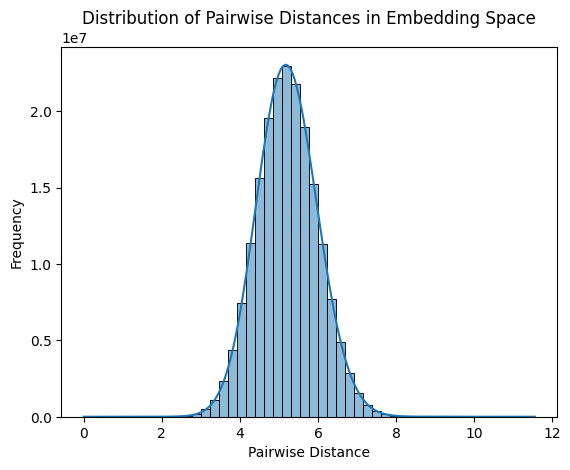

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(distances, bins=50, kde=True)
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency") 
plt.title("Distribution of Pairwise Distances in Embedding Space")
plt.show()

Dimension 0: Mean = -0.0436, Std Dev = 0.5194
Dimension 1: Mean = -0.7957, Std Dev = 0.7054
Dimension 2: Mean = -0.4885, Std Dev = 0.7750
Dimension 3: Mean = 0.0076, Std Dev = 0.5273
Dimension 4: Mean = 0.2820, Std Dev = 0.8325
Dimension 5: Mean = -0.4127, Std Dev = 0.6280
Dimension 6: Mean = 0.0264, Std Dev = 0.5453
Dimension 7: Mean = -0.9723, Std Dev = 0.7690
Dimension 8: Mean = -0.3839, Std Dev = 0.6844
Dimension 9: Mean = -0.1254, Std Dev = 0.7981
Dimension 10: Mean = 0.8704, Std Dev = 0.8812
Dimension 11: Mean = -0.3635, Std Dev = 0.5295
Dimension 12: Mean = -0.5665, Std Dev = 0.6435
Dimension 13: Mean = -0.0183, Std Dev = 0.8306
Dimension 14: Mean = -0.2788, Std Dev = 0.6914
Dimension 15: Mean = -0.2139, Std Dev = 0.7013
Dimension 16: Mean = -0.2167, Std Dev = 0.3660
Dimension 17: Mean = 0.7869, Std Dev = 0.7283
Dimension 18: Mean = -0.5305, Std Dev = 0.8829
Dimension 19: Mean = -0.0107, Std Dev = 0.4854
Dimension 20: Mean = -0.1307, Std Dev = 0.5507
Dimension 21: Mean = 0.0479,

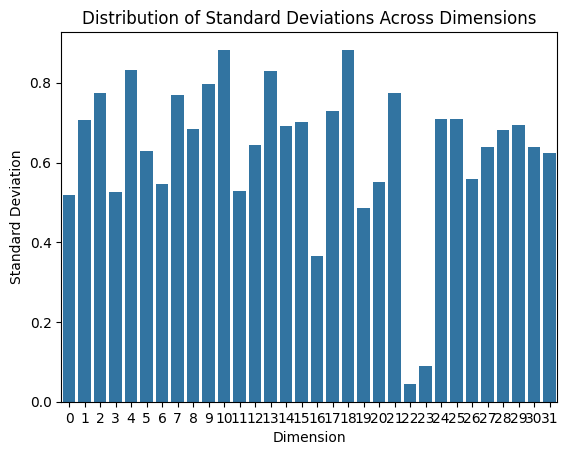

In [3]:
# for each dimention calculate the mean and std_deviation
for i in range(_embeddings.shape[1]):
    dim_values = _embeddings[:, i]
    mean = np.mean(dim_values)
    std_dev = np.std(dim_values)
    print(f"Dimension {i}: Mean = {mean:.4f}, Std Dev = {std_dev:.4f}")
    
# make a barplot of the std_deviation of each dimension
std_devs = [np.std(_embeddings[:, i]) for i in range(_embeddings.shape[1])]
sns.barplot(x=list(range(len(std_devs))), y=std_devs)
plt.xlabel("Dimension")
plt.ylabel("Standard Deviation")
plt.title("Distribution of Standard Deviations Across Dimensions")
plt.show()

Autovalori: [1.42884661e+00 1.20585547e+00 1.08509388e+00 1.05399979e+00
 9.08260184e-01 7.36725240e-01 6.82155123e-01 6.71653936e-01
 6.14450366e-01 5.49982100e-01 5.15623628e-01 2.60570578e-03
 5.09530409e-04 2.43711262e-02 4.65591870e-01 6.95856463e-02
 4.25775156e-01 9.51982168e-02 1.10317912e-01 1.28855210e-01
 1.55438486e-01 1.72668177e-01 1.90273932e-01 2.09958145e-01
 2.28214878e-01 2.47961416e-01 3.71317248e-01 2.82624482e-01
 2.99390306e-01 3.42974500e-01 3.12261748e-01 3.28865158e-01]


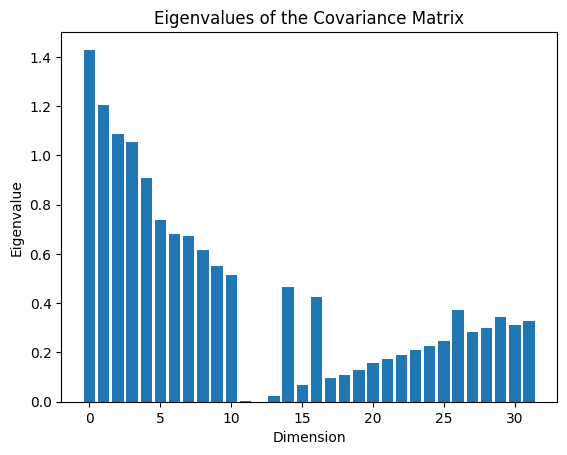

In [4]:
# covariance matrix and eigenvalues
cov_matrix = np.cov(_embeddings, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Autovalori:", eigenvalues)

# bar plot of eigenvalues
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.xlabel("Dimension")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Covariance Matrix")
plt.show()